# Probabilistic Reasoning: Bayes' Theorem

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply Bayes' theorem to update probabilities
- Use prior, likelihood, and posterior in simple examples

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 10 "Knowledge Representation and Reasoning" — reasoning with *certain* facts; Bayes is reasoning when the facts are uncertain.

**Used later in:** Course 02 (AIAT 112) — Unit 3, where Bayes' rule scales up to Bayesian networks and HMMs.

---


## 🎯 The question that 95 doctors out of 100 got wrong

In 1982 David Eddy put a question to practising American physicians. A woman has
a positive screening mammogram. The prevalence of breast cancer in the screened
population is **1%**; the test's sensitivity is **80%**; its false-positive rate
is **9.6%**. What is the probability she has cancer?

About **95 out of 100 physicians answered around 75%**. The correct answer is
**7.7%** — roughly one in thirteen. The doctors were not bad at arithmetic. They
were reading the test's accuracy as if it were the answer, and ignoring the fact
that in a population where only 1% are ill, the small false-positive rate applied
to the 99% who are healthy produces far more positive results than the disease does.

That mistake has a name — **base-rate neglect** — and it is not a curiosity. It
is repeated every time a screening programme is designed, every time a fraud
filter is deployed, and every time someone quotes a model's accuracy without
mentioning how rare the thing it detects is. The very first cell below computes
that exact calculation on numbers of the same shape, and prints **8.76%**.

### What goes wrong without Bayes' theorem

You confuse two different questions: *"how often does the test fire when the
disease is present?"* (sensitivity, 95% below) and *"how often is the disease
present when the test fires?"* (the posterior, 8.76% below). They are different
numbers, sometimes by a factor of ten, and the second one is the only one the
patient cares about. Bayes' theorem is the rule that converts between them, and
it is the reason a Unit 5 medical classifier reports precision and recall rather
than a single accuracy figure.


# Probabilistic Reasoning: Bayes' Theorem

**Unit:** Unit 2: AI Concepts, Terminology, and Application Domains  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand uncertainty in AI and why it matters
- Learn Bayes' theorem and its formula
- Apply Bayes' rule to real-world problems
- Implement Bayesian reasoning in Python
- Understand Bayesian statistics applications

---

## Bayes' Theorem Formula

**P(A|B) = P(B|A) × P(A) / P(B)**

Where:
- **P(A|B)**: Posterior probability (probability of A given B)
- **P(B|A)**: Likelihood (probability of B given A)
- **P(A)**: Prior probability (probability of A)
- **P(B)**: Evidence (probability of B)

**In AI Context:**
- A = Hypothesis (e.g., patient has disease)
- B = Evidence (e.g., test result)
- P(A|B) = Updated belief after seeing evidence


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Example 1: Medical Diagnosis with Bayes' Theorem

def bayes_theorem(prior, likelihood, evidence):
    """
    Calculate posterior probability using Bayes' theorem
    
    Args:
        prior: P(A) - prior probability
        likelihood: P(B|A) - likelihood
        evidence: P(B) - evidence probability
    
    Returns:
        P(A|B) - posterior probability
    """
    posterior = (likelihood * prior) / evidence
    return posterior

# Medical test example
# Suppose:
# - Disease prevalence (prior): 1% of population
# - Test sensitivity (likelihood): 95% (P(positive|disease))
# - Test specificity: 90% (P(negative|no_disease))
# - What is P(disease|positive_test)?

prior_disease = 0.01  # 1% have the disease
sensitivity = 0.95    # 95% true positive rate
specificity = 0.90    # 90% true negative rate

# Calculate P(positive_test)
# P(positive) = P(positive|disease) * P(disease) + P(positive|no_disease) * P(no_disease)
p_positive_given_disease = sensitivity
p_positive_given_no_disease = 1 - specificity  # False positive rate
p_no_disease = 1 - prior_disease

p_positive = (p_positive_given_disease * prior_disease) + \
             (p_positive_given_no_disease * p_no_disease)

# Calculate posterior: P(disease|positive_test)
p_disease_given_positive = bayes_theorem(
    prior=prior_disease, likelihood=p_positive_given_disease,
    evidence=p_positive
)

print("=== Medical Diagnosis Example ===")
print(f"Prior probability of disease: {prior_disease:.2%}")
print(f"Test sensitivity: {sensitivity:.2%}")
print(f"Test specificity: {specificity:.2%}")
print(f"\nProbability of positive test: {p_positive:.2%}")
print(f"\nPosterior probability (disease given positive test): {p_disease_given_positive:.2%}")
print(f"\nEven with a positive test, probability is only {p_disease_given_positive:.2%}!")

=== Medical Diagnosis Example ===
Prior probability of disease: 1.00%
Test sensitivity: 95.00%
Test specificity: 90.00%

Probability of positive test: 10.85%

Posterior probability (disease given positive test): 8.76%

Even with a positive test, probability is only 8.76%!


In [2]:
# Example 2: Spam Email Detection

def spam_detector(word, prior_spam, word_given_spam, word_given_ham):
    """
    Simple spam detector using Bayes' theorem
    """
    # P(spam|word) = P(word|spam) * P(spam) / P(word)
    # P(word) = P(word|spam) * P(spam) + P(word|ham) * P(ham)
    
    prior_ham = 1 - prior_spam
    p_word = (word_given_spam * prior_spam) + (word_given_ham * prior_ham)
    
    # Calculate P(spam|word) using Bayes' theorem
    p_spam_given_word = (word_given_spam * prior_spam) / p_word
    return p_spam_given_word

# Example: Word "free" in email
prior_spam_prob = 0.3  # 30% of emails are spam
p_free_given_spam = 0.8  # 80% of spam emails contain "free"
p_free_given_ham = 0.1    # 10% of ham emails contain "free"

spam_probability = spam_detector(
    word="free", prior_spam=prior_spam_prob,
    word_given_spam=p_free_given_spam,
    word_given_ham=p_free_given_ham
)

print("\n=== Spam Detection Example ===")
print(f"Prior spam probability: {prior_spam_prob:.2%}")
print(f"P('free'|spam): {p_free_given_spam:.2%}")
print(f"P('free'|ham): {p_free_given_ham:.2%}")
print(f"\nP(spam|'free'): {spam_probability:.2%}")
print(f"\nEmail with 'free' is {spam_probability:.2%} likely to be spam")


=== Spam Detection Example ===
Prior spam probability: 30.00%
P('free'|spam): 80.00%
P('free'|ham): 10.00%

P(spam|'free'): 77.42%

Email with 'free' is 77.42% likely to be spam


## 📊 One theorem, two priors, two very different answers

The two cells applied the identical rule and changed one input — the **prior**:

| example | prior P(H) | evidence strength | posterior P(H \| E) | belief moved |
|---|---|---|---|---|
| Disease test | **1%** | sensitivity 95%, specificity 90% | **8.76%** | ×8.8, still small |
| Spam word "free" | **30%** | P(free\|spam) 80% vs P(free\|ham) 10% | **77.42%** | ×2.6, now decisive |

**The conclusion these numbers support:** the *same* strength of evidence produces
a confident answer in one case and an inconclusive one in the other, and the only
difference is the base rate. The disease test is the stronger instrument on paper
— 95% sensitivity against the spam word's 80% — and it still leaves you at 8.76%,
because it is looking for something that is rare. **Evidence updates belief; it
does not replace it.**

**The practical rule to take away:** whenever someone quotes a detection rate, ask
what fraction of the population has the thing being detected. Without that number,
the detection rate alone cannot tell you what a positive result means.

### 🔁 The same reasoning shows up here too

- **Airport and border screening:** a highly accurate check applied to a
  population where the target is very rare produces overwhelmingly false alerts.
- **Bank fraud alerts:** fraud is a fraction of a percent of transactions, which
  is why fraud teams are judged on precision, not on detection rate.
- **Rare-disease genetic testing:** the reason clinical guidelines restrict some
  tests to high-risk groups is that raising the prior is the only way to make the
  posterior usable.


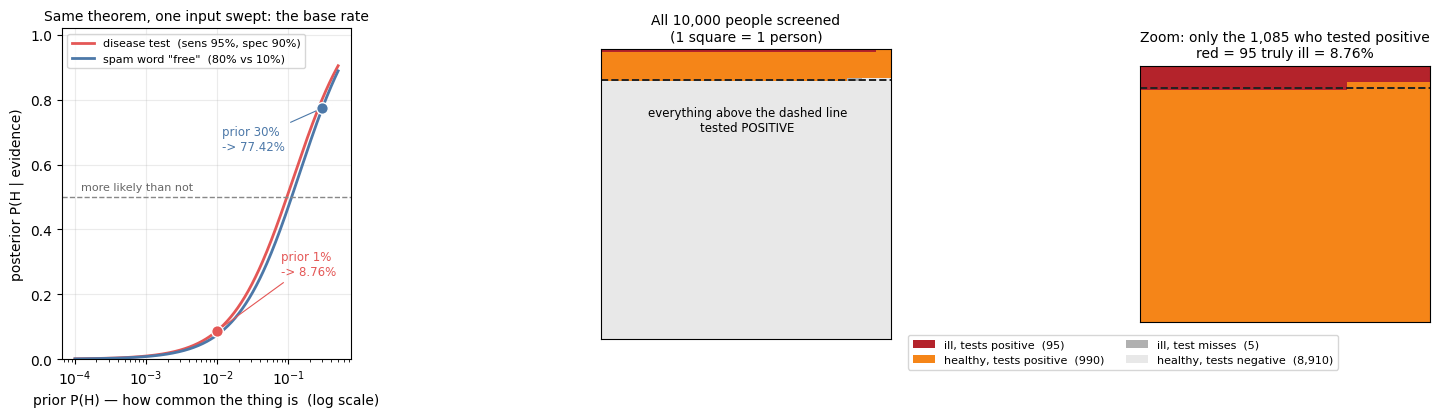

Natural frequencies out of 10,000 people at a 1% base rate:
  ill and positive   : 95
  healthy but positive: 990
  P(ill | positive)  = 95/(95+990) = 8.76%   (matches the 8.76% computed above)
  Prior needed before ONE positive test passes 50%: 9.6%

Same disease test, moved to the spam example's 30% prior: 80.28% (vs the spam word's 77.42%) — the instrument was never the problem.


In [3]:
# 📊 FIGURE — why the same evidence lands in two different places.
# WHAT: we reuse the EXACT numbers from the two cells above (disease: sensitivity 0.95,
#       specificity 0.90; spam word "free": P(word|spam) 0.80, P(word|ham) 0.10) and
#       sweep only ONE input — the prior — across the whole plausible range.
# WHY: the printed answers (8.76% and 77.42%) look like facts about the two tests.
#      The sweep shows they are mostly facts about the two priors.
import numpy as np
import matplotlib.pyplot as plt


def posterior(prior, p_e_given_h, p_e_given_not_h):
    """Bayes' rule, written once and used for both examples."""
    evidence = p_e_given_h * prior + p_e_given_not_h * (1 - prior)
    return p_e_given_h * prior / evidence


priors = np.logspace(-4, np.log10(0.5), 300)     # 0.01% up to 50% base rate
post_disease = posterior(priors, sensitivity, 1 - specificity)          # 0.95 / 0.10
post_spam = posterior(priors, p_free_given_spam, p_free_given_ham)      # 0.80 / 0.10

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(14.5, 4.4))

# --- A: posterior as a function of the base rate ---------------------------
axA.plot(priors, post_disease, color="#E45756", lw=2,
         label="disease test  (sens 95%, spec 90%)")
axA.plot(priors, post_spam, color="#4C78A8", lw=2,
         label='spam word "free"  (80% vs 10%)')
axA.scatter([prior_disease], [p_disease_given_positive], color="#E45756",
            s=70, zorder=5, edgecolor="white")
axA.annotate(f"prior 1%\n-> {p_disease_given_positive:.2%}",
             (prior_disease, p_disease_given_positive),
             textcoords="offset points", xytext=(46, 40), fontsize=8.5, color="#E45756",
             arrowprops=dict(arrowstyle="-", color="#E45756", lw=0.8))
axA.scatter([prior_spam_prob], [spam_probability], color="#4C78A8",
            s=70, zorder=5, edgecolor="white")
axA.annotate(f"prior 30%\n-> {spam_probability:.2%}", (prior_spam_prob, spam_probability),
             textcoords="offset points", xytext=(-72, -30), fontsize=8.5, color="#4C78A8",
             arrowprops=dict(arrowstyle="-", color="#4C78A8", lw=0.8))
axA.axhline(0.5, color="#888", ls="--", lw=1)
axA.text(1.2e-4, 0.52, "more likely than not", fontsize=8, color="#666")
axA.set_xscale("log")
axA.set_xlabel("prior P(H) — how common the thing is  (log scale)")
axA.set_ylabel("posterior P(H | evidence)")
axA.set_ylim(0, 1.02)
axA.set_title("Same theorem, one input swept: the base rate", fontsize=10)
axA.legend(fontsize=8, loc="upper left")
axA.grid(alpha=0.25)

# --- B: the same 8.76% as 10,000 whole people (no rounding needed) ----------
N = 10_000
n_sick = int(N * prior_disease)                       # 100 people are ill
tp = int(round(n_sick * sensitivity))                 # 95 of them test positive
fn = n_sick - tp                                      # 5 are missed
n_well = N - n_sick                                   # 9,900 are healthy
fp = int(round(n_well * (1 - specificity)))           # 990 of THEM test positive too
tn = n_well - fp

CMAP = plt.matplotlib.colors.ListedColormap(
    ["#E8E8E8", "#B0B0B0", "#F58518", "#B4232B", "#FFFFFF"])
LABELS = [f"ill, tests positive  ({tp})", f"healthy, tests positive  ({fp})",
          f"ill, test misses  ({fn})", f"healthy, tests negative  ({tn:,})"]
handles = [plt.Rectangle((0, 0), 1, 1, fc=c)
           for c in ["#B4232B", "#F58518", "#B0B0B0", "#E8E8E8"]]

# Everyone who tested POSITIVE is drawn first, so they form one block at the top.
codes = np.array([3] * tp + [2] * fp + [1] * fn + [0] * tn).reshape(100, 100)
axB.imshow(codes, cmap=CMAP, vmin=0, vmax=4, interpolation="nearest")
cut = (tp + fp) / 100 - 0.5
axB.axhline(cut, color="#222", ls="--", lw=1.4)
axB.text(50, cut + 9, "everything above the dashed line\ntested POSITIVE",
         ha="center", va="top", fontsize=8.5)
axB.set_xticks([]); axB.set_yticks([])
axB.set_title(f"All {N:,} people screened\n(1 square = 1 person)", fontsize=10)

# --- C: zoom on the block that matters — the people who tested positive -----
n_pos = tp + fp
cols = 35
rows = int(np.ceil(n_pos / cols))
pad = rows * cols - n_pos
zoom = np.array([3] * tp + [2] * fp + [4] * pad).reshape(rows, cols)
axC.imshow(zoom, cmap=CMAP, vmin=0, vmax=4, interpolation="nearest")
axC.axhline(tp / cols - 0.5, color="#222", ls="--", lw=1.4)
axC.set_xticks([]); axC.set_yticks([])
axC.set_title(f"Zoom: only the {n_pos:,} who tested positive\n"
              f"red = {tp} truly ill = {tp / n_pos:.2%}", fontsize=10)
axC.legend(handles, LABELS, fontsize=8, loc="upper center",
           bbox_to_anchor=(-0.06, -0.03), ncol=2)

plt.tight_layout()
plt.show()

print(f"Natural frequencies out of {N:,} people at a {prior_disease:.0%} base rate:")
print(f"  ill and positive   : {tp}")
print(f"  healthy but positive: {fp}")
print(f"  P(ill | positive)  = {tp}/({tp}+{fp}) = {tp / (tp + fp):.2%}"
      f"   (matches the {p_disease_given_positive:.2%} computed above)")
print(f"  Prior needed before ONE positive test passes 50%: "
      f"{priors[np.argmax(post_disease >= 0.5)]:.1%}")
print(f"\nSame disease test, moved to the spam example's 30% prior: "
      f"{posterior(prior_spam_prob, sensitivity, 1 - specificity):.2%} "
      f"(vs the spam word's {spam_probability:.2%}) — the instrument was never the problem.")

### 👁️ Read the figure

**Left — the two curves never cross, and the red one is always on top.** The
disease test is the stronger instrument at *every* base rate: 95% sensitivity
against the spam word's 80%, so its posterior is higher for any prior you pick.
Yet the red dot sits at **8.76%** and the blue dot at **77.42%**. The only thing
that separates them is *where on the x-axis they live* — the disease is at 1%,
the spam prior at 30%. Slide the red dot rightwards along its own curve and it
overtakes the blue one immediately. **A better test applied to a rarer thing
still gives you a weaker answer.**

Move the red dot to the blue dot's prior and the point lands: at a 30% base rate
the disease test returns **80.28%**, better than the spam word's 77.42%. The
instrument was never the problem — the base rate was.

Read the shape too: both curves are almost flat and near zero across the left
half of the plot. Below a base rate of about 1 in 1,000, a single positive result
from either test means almost nothing — which is the whole design problem in
screening, fraud detection and airport security.

**Middle — the same 8.76%, with no arithmetic at all.** Every square is one of
10,000 screened people, and **everyone above the dashed line got a positive
result**. Notice how thin that band is against the grey field under it: 8,915
people are told, correctly, that nothing is wrong.

**Right — zoom into that band.** These are *only* the 1,085 people holding a
positive result. The dark red block at the top is the **95 who are ill**;
everything orange below it is the **990 who are healthy and tested positive
anyway** — ten times more, because the 10% false-positive rate is applied to the
9,900 healthy people rather than to the 100 ill ones. The red block occupies
**8.76% of the picture**. That is the posterior, obtained by looking rather than
by dividing.

**What this proves:** the grey field is why. A rare condition means almost
everybody feeding into the test is healthy, so even a small error rate on that
huge group out-produces the disease itself.

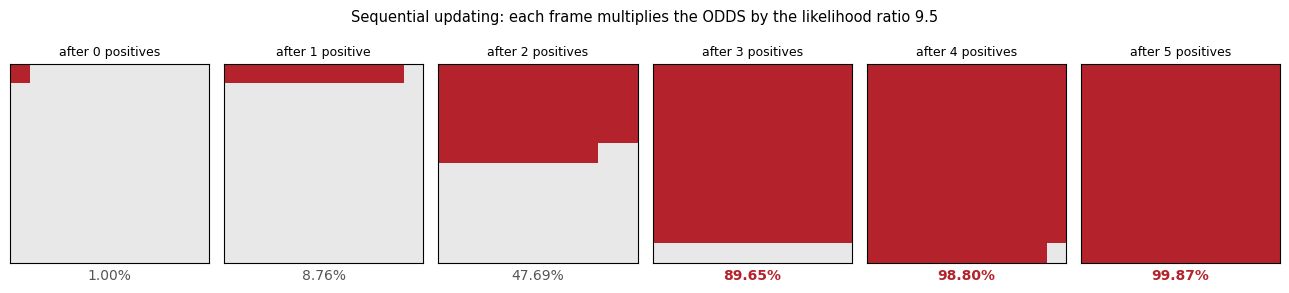

step  positives so far        odds   posterior
   0                 0      0.0101      1.00%
   1                 1      0.0960      8.76%
   2                 2      0.9116     47.69%
   3                 3      8.6604     89.65%
   4                 4     82.2734     98.80%
   5                 5    781.5969     99.87%

First step at which the posterior passes 50%: 3 positive tests.
⚠️ This assumes each test is INDEPENDENT given the true state. Repeating the same test on the same person usually violates that — the same biological or instrumental quirk fires again — so real sequential testing uses a DIFFERENT test.


In [4]:
# 🎞️ STEP STORYBOARD — belief updating, one positive test at a time.
# WHAT: a static row of snapshots instead of an animation, so it renders identically
#       everywhere. Frame k shows the posterior after k independent positive results,
#       drawn as a 10x10 icon array: each square is 1 of 100 people in the same
#       situation, and the filled squares are those who really are ill.
# WHY: one positive test leaves you at 8.76% and students conclude the test is useless.
#      Watching the belief march across the frames shows what actually changes it.
import numpy as np
import matplotlib.pyplot as plt

# The likelihood ratio of a positive result: how many times more often a positive
# appears in the ill than in the healthy. Multiplying ODDS by it IS Bayes' rule.
lr_pos = sensitivity / (1 - specificity)

N_STEPS = 6                                   # cheap: 6 frames, no animation loop
odds = prior_disease / (1 - prior_disease)
posteriors = []
for k in range(N_STEPS):
    posteriors.append(odds / (1 + odds))
    odds *= lr_pos                            # one more positive test

fig, axes = plt.subplots(1, N_STEPS, figsize=(13, 2.9))
for k, ax in enumerate(axes):
    p = posteriors[k]
    filled = int(round(p * 100))              # people out of 100 who are truly ill
    grid = np.array([1] * filled + [0] * (100 - filled)).reshape(10, 10)
    ax.imshow(grid, cmap=plt.matplotlib.colors.ListedColormap(["#E8E8E8", "#B4232B"]),
              vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"after {k} positive{'s' if k != 1 else ''}", fontsize=9)
    ax.set_xlabel(f"{p:.2%}", fontsize=10,
                  color="#B4232B" if p >= 0.5 else "#555",
                  fontweight="bold" if p >= 0.5 else "normal")
fig.suptitle(f"Sequential updating: each frame multiplies the ODDS by the "
             f"likelihood ratio {lr_pos:.1f}", fontsize=10.5)
plt.tight_layout()
plt.show()

# The printed step table — the numbers behind the frames, so nothing is taken on trust.
print(f"{'step':>4}  {'positives so far':>16}  {'odds':>10}  {'posterior':>10}")
o = prior_disease / (1 - prior_disease)
for k in range(N_STEPS):
    print(f"{k:>4}  {k:>16}  {o:>10.4f}  {o / (1 + o):>9.2%}")
    o *= lr_pos
first_over_half = next(k for k, p in enumerate(posteriors) if p >= 0.5)
print(f"\nFirst step at which the posterior passes 50%: {first_over_half} positive tests.")
print("⚠️ This assumes each test is INDEPENDENT given the true state. Repeating the "
      "same test on the same person usually violates that — the same biological or "
      "instrumental quirk fires again — so real sequential testing uses a DIFFERENT test.")

### 👁️ Read the storyboard

Six frames, one extra positive test each. Every frame is 100 people who all got
the same run of results; the red squares are how many of them are really ill.

- **Frame 0** — the prior. One red square in a hundred: this is the whole
  population before any test.
- **Frame 1** — the 8.76% from the cell above. Nine red squares. A positive test
  has multiplied the odds by **9.5**, and it is *still* a minority of the people
  holding that result.
- **Frame 2** — 47.69%. Not yet a coin flip.
- **Frame 3** — 89.65%. **This is the frame where the block turns red**: it takes
  three independent positive results, not one, to move a 1-in-100 condition into
  "probably true".
- **Frames 4 and 5** — 98.80% and 99.87%. The gain per test collapses once you
  are already confident; the last frame adds one square.

**What this proves:** the 8.76% was never a verdict that the test is bad. Each
positive multiplies the *odds* by the same factor (9.5), and odds starting at
1:99 need several multiplications to get anywhere. That is exactly why screening
programmes are built as **sequences** — a cheap wide test, then a different,
harder confirmatory one.

**The honest limit, printed under the frames:** this multiplication is only valid
if the tests are independent given the truth. Run the *same* test three times on
the same person and the same quirk that produced the first false positive will
tend to produce the next two, so the real posterior is lower than frame 3 claims.
Sequences in medicine use a *different* second test for precisely this reason.

## 💬 Discuss

Read the two printed results before answering: the disease test moved belief from
a 1% prior to an **8.76% posterior**, and the word "free" moved a 30% prior to
**77.42%**.

1. A positive test raised the probability of disease from 1% to 8.76% — so about
   **91 of every 100 people who test positive do not have the disease**. Would you
   run this screening programme? Argue it as the health ministry paying for the
   follow-up tests, then argue it as one of the 1% who has the disease. Nothing
   about the arithmetic changes; say what does.
2. The spam example used a single word. Real filters use thousands and assume the
   words are independent given the class — which is plainly false (*free* and
   *offer* travel together). The assumption is wrong and the filters work anyway.
   **Why might a wrong assumption still produce good decisions**, and what kind of
   error should you expect it to produce when it fails?
3. **Regional practice:** a diagnostic model is trained where a disease affects 1
   in 100, and deployed where it affects 1 in 2,000. The likelihood terms are
   unchanged. Work out what happens to the posterior, then decide what you would
   demand from a vendor before letting the model into a Saudi hospital.


## ⚠️ Where this breaks

Bayes' theorem is arithmetic — it is always correct. What breaks is everything
you have to supply to use it.

- **The prior has to come from somewhere.** We typed `0.01`. In practice that
  number comes from an epidemiological study on some population, at some time, and
  it does not transfer: prevalence differs by country, age band, season and how
  people were selected into the sample. **A posterior is only as defensible as
  the prior underneath it**, and priors are where the arguing happens.
- **Sensitivity and specificity are estimates too.** 95% and 90% were measured on
  a validation cohort with its own selection effects. If the test performs
  differently on the population you deploy to, the posterior is wrong and nothing
  in the calculation warns you.
- **The spam calculation assumes conditional independence, which is false.**
  Naive Bayes multiplies per-word probabilities as if the words were unrelated.
  Because they are correlated, it typically produces **badly calibrated
  confidences** — 0.99 when it should say 0.80 — even when the *ranking* it
  produces is good enough to classify with. Use it to decide; do not quote its
  probability as a probability.
- **One piece of evidence is the easy case.** Combining several tests requires
  either an independence assumption (usually wrong) or a full joint model, and the
  number of parameters explodes with the number of variables. That is what
  Bayesian networks (Course 02, Unit 3) exist to manage.
- **Base rates move.** Prevalence changes with an outbreak, a screening campaign,
  or a change in who gets referred. A system that hard-codes a prior degrades
  silently as the world shifts underneath it — and the output looks exactly as
  confident as it did on day one.
- **Cheaper alternative when you cannot defend a prior:** report the likelihood
  ratio instead (`P(evidence | disease) / P(evidence | no disease)`), and let the
  clinician supply the prior they believe. That separates what your data measured
  from what someone assumed.


## 📚 References

1. Bayes, T. (1763). *An Essay towards Solving a Problem in the Doctrine of Chances*. Philosophical Transactions of the Royal Society, 53, 370–418.
2. Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems: Networks of Plausible Inference*. Morgan Kaufmann.
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chs. 1–2. Springer.
4. Papamarkou, T., Skoularidou, M., Palla, K., et al. (2024). *Position: Bayesian Deep Learning is Needed in the Age of Large-Scale AI*. arXiv. <https://arxiv.org/abs/2402.00809>